In [22]:
!pip install rosbags matplotlib numpy scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 13.7 MB/s  0:00:02 eta 0:00:01


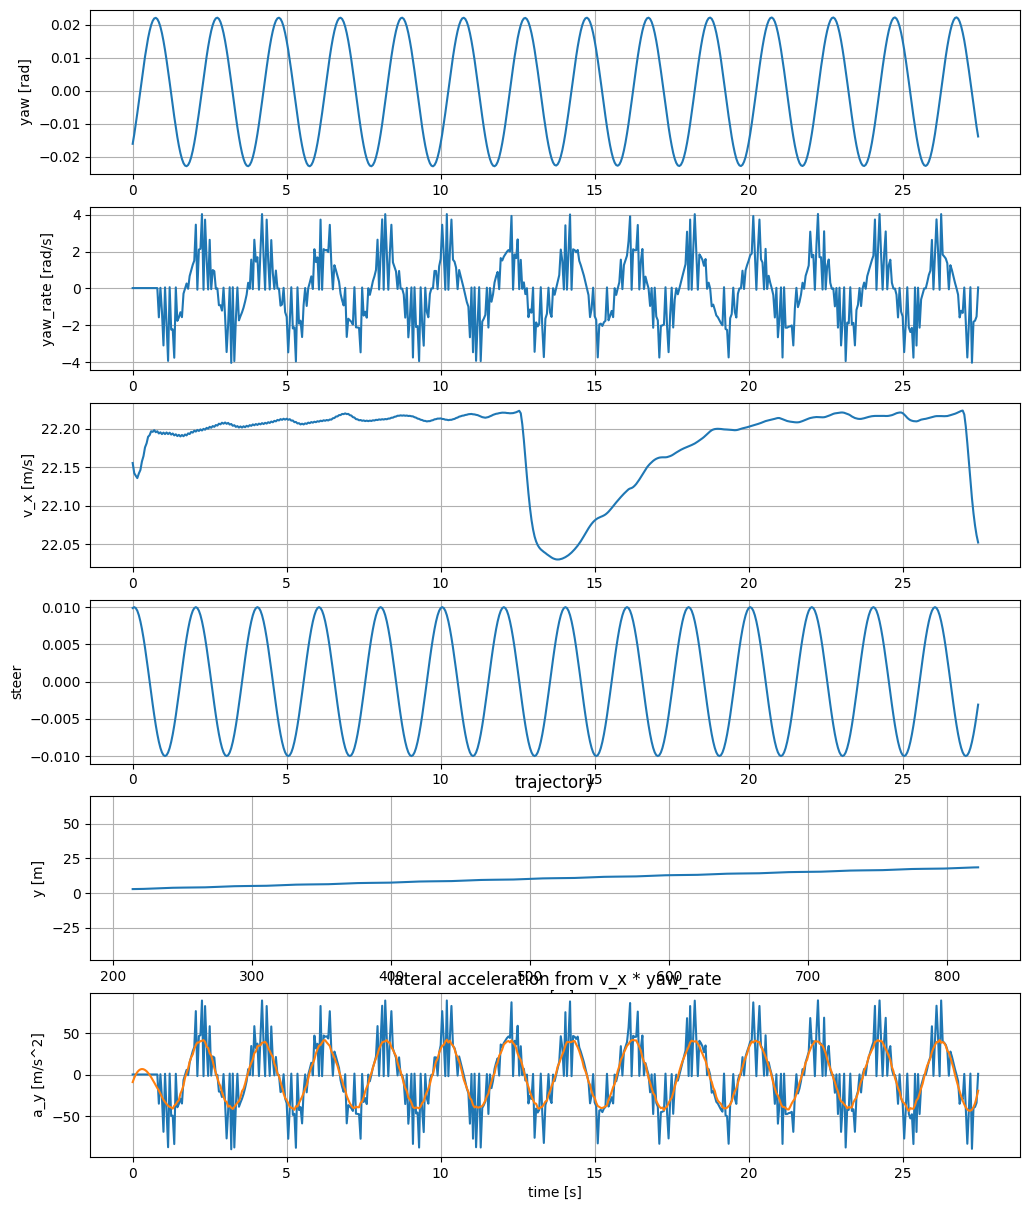

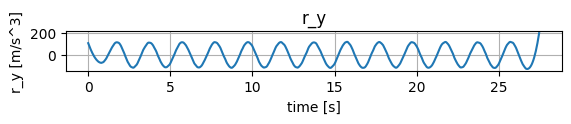

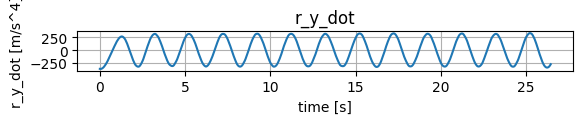

<Figure size 640x480 with 0 Axes>

In [ ]:
from rosbags.rosbag2 import Reader
from rosbags.typesys import Stores, get_typestore
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

bag_path = '/home/user/auto_ws/workspace/rosbag2_2026_03_29-23_23_51'

typestore = get_typestore(Stores.ROS2_HUMBLE)

yaw_t, yaw = [], []
imu_t, yaw_rate = [], []
vel_t, vx = [], []
steer_t, steer = [], []
pos_t, px, py = [], [], []

with Reader(bag_path) as reader:
    for connection, timestamp, rawdata in reader.messages():
        msg = typestore.deserialize_cdr(rawdata, connection.msgtype)

        if connection.topic == '/carla/hero/yaw':
            t = msg.header.stamp.sec + msg.header.stamp.nanosec * 1e-9
            yaw_t.append(t)
            yaw.append(msg.vector.z)

        elif connection.topic == '/carla/hero/imu_stamped':
            t = msg.header.stamp.sec + msg.header.stamp.nanosec * 1e-9
            imu_t.append(t)
            yaw_rate.append(msg.angular_velocity.z)

        elif connection.topic == '/carla/hero/velocity_stamped':
            t = msg.header.stamp.sec + msg.header.stamp.nanosec * 1e-9
            vel_t.append(t)
            vx.append(msg.vector.x)

        elif connection.topic == '/carla/hero/steer_stamped':
            t = msg.header.stamp.sec + msg.header.stamp.nanosec * 1e-9
            steer_t.append(t)
            steer.append(msg.vector.x)

        elif connection.topic == '/carla/hero/position_stamped':
            t = msg.header.stamp.sec + msg.header.stamp.nanosec * 1e-9
            pos_t.append(t)
            px.append(msg.vector.x)
            py.append(msg.vector.y)

# numpy
yaw_t = np.array(yaw_t)
yaw = np.array(yaw)

imu_t = np.array(imu_t)
yaw_rate = np.array(yaw_rate)

vel_t = np.array(vel_t)
vx = np.array(vx)

steer_t = np.array(steer_t)
steer = np.array(steer)

pos_t = np.array(pos_t)
px = np.array(px)
py = np.array(py)

# нормализация времени
t0 = yaw_t[0]
yaw_t -= t0
imu_t -= t0
vel_t -= t0
steer_t -= t0
pos_t -= t0

# unwrap yaw
yaw = np.arctan2(np.sin(yaw), np.cos(yaw))
yaw -= np.mean(yaw)

# интерполяция
yaw_rate_interp = np.interp(yaw_t, imu_t, yaw_rate)
vx_interp = np.interp(yaw_t, vel_t, vx)
steer_interp = np.interp(yaw_t, steer_t, steer)

px_interp = np.interp(yaw_t, pos_t, px)
py_interp = np.interp(yaw_t, pos_t, py)

a_y_from_yaw = vx_interp * yaw_rate_interp
a_y = a_y_from_yaw.copy()
a_y_smooth = savgol_filter(a_y, 31, 3)

dt = np.mean(np.diff(yaw_t))

r_y = np.gradient(a_y_smooth, dt)
r_y_smooth = savgol_filter(r_y, 31, 3)

r_y_dot = np.gradient(r_y_smooth, dt)
r_y_dot_smooth = savgol_filter(r_y_dot, 31, 3)

# -------- графики --------
plt.figure(figsize=(12, 20))

n = 8

plt.subplot(n,1,1)
plt.plot(yaw_t, yaw)
plt.ylabel('yaw [rad]')
plt.grid()

plt.subplot(n,1,2)
plt.plot(yaw_t, yaw_rate_interp)
plt.ylabel('yaw_rate [rad/s]')
plt.grid()

plt.subplot(n,1,3)
plt.plot(yaw_t, vx_interp)
plt.ylabel('v_x [m/s]')
plt.grid()

plt.subplot(n,1,4)
plt.plot(yaw_t, steer_interp)
plt.ylabel('steer')
plt.grid()

plt.subplot(n,1,5)
plt.plot(px, py)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('trajectory')
plt.axis('equal')
plt.grid()

plt.subplot(n,1,6)
plt.plot(yaw_t, a_y_from_yaw)
plt.plot(yaw_t, a_y_smooth)
plt.ylabel('a_y [m/s^2]')
plt.xlabel('time [s]')
plt.title('lateral acceleration from v_x * yaw_rate')
plt.grid()
plt.show()

plt.subplot(n,1,7)
plt.plot(yaw_t, r_y_smooth)
plt.ylabel('r_y [m/s^3]')
plt.xlabel('time [s]')
plt.title('r_y')
plt.grid()
plt.show()

plt.subplot(n,1,8)
plt.plot(yaw_t, r_y_smooth)
plt.ylabel('r_y_dot [m/s^4]')
plt.xlabel('time [s]')
plt.title('r_y_dot')
plt.grid()
plt.show()

plt.tight_layout()
plt.show()

In [31]:
end = -20
X = np.column_stack([
    a_y_smooth[:end],
    r_y_smooth[:end],
    steer_interp[:end]
])

y_target = r_y_dot_smooth[:end]

coef, *_ = np.linalg.lstsq(X, y_target, rcond=None)
c1, c2, c3 = coef

print('c1 =', c1)
print('c2 =', c2)
print('c3 =', c3)

c1 = 2.025920732213813
c2 = 2.1914505228519374
c3 = -47254.5433345395


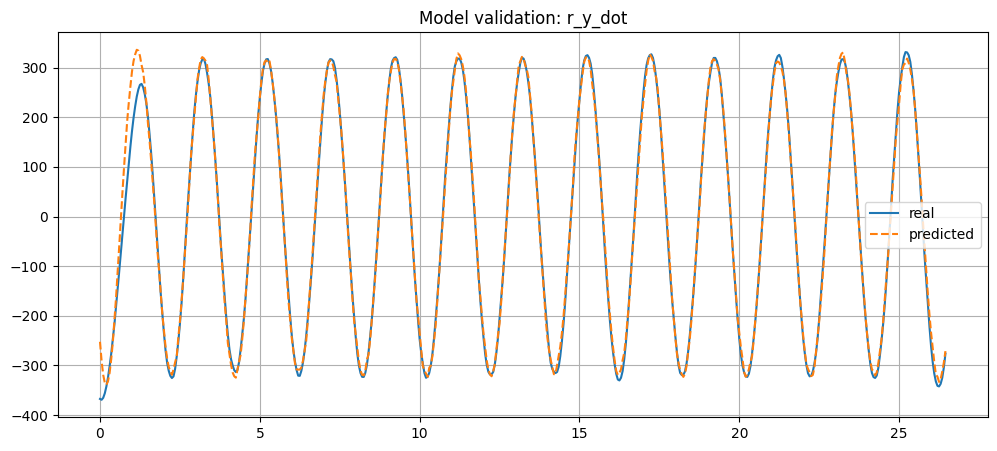

In [34]:
r_y_dot_pred = c1 * a_y_smooth + c2 * r_y_smooth + c3 * steer_interp

plt.figure(figsize=(12,5))
plt.plot(yaw_t[:end], r_y_dot_smooth[:end], label='real')
plt.plot(yaw_t[:end], r_y_dot_pred[:end], '--', label='predicted')
plt.legend()
plt.grid()
plt.title('Model validation: r_y_dot')
plt.show()

In [35]:
T_C = np.sqrt(-1.0 / c1)
D_C = -(c2 * T_C) / 2.0
K_C = c3 * T_C**2

print('\n--- Identified parameters ---')
print('T_C =', T_C)
print('D_C =', D_C)
print('K_C =', K_C)


--- Identified parameters ---
T_C = nan
D_C = nan
K_C = nan


/tmp/ipykernel_434208/2604175647.py:1: RuntimeWarning: invalid value encountered in sqrt
  T_C = np.sqrt(-1.0 / c1)


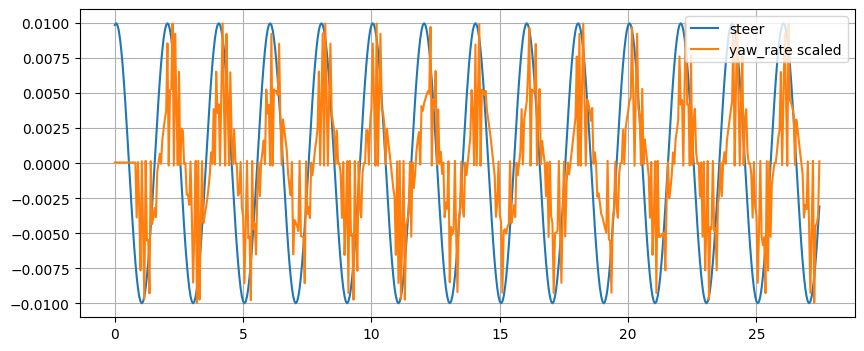

In [36]:
plt.figure(figsize=(10,4))
plt.plot(yaw_t, steer_interp, label='steer')
plt.plot(yaw_t, yaw_rate_interp / np.max(np.abs(yaw_rate_interp)) * np.max(np.abs(steer_interp)), label='yaw_rate scaled')
plt.legend()
plt.grid()
plt.show()